Veri setinin son gözlemleri:
            inflation  interest  exchange
date                                     
2024-08-01      51.97      50.0     33.85
2024-09-01      49.38      50.0     34.12
2024-10-01      48.58      50.0     34.28
2024-11-01      47.09      47.5     34.52
2024-12-01      44.38      47.5     34.85

Toplam gözlem sayısı: 120


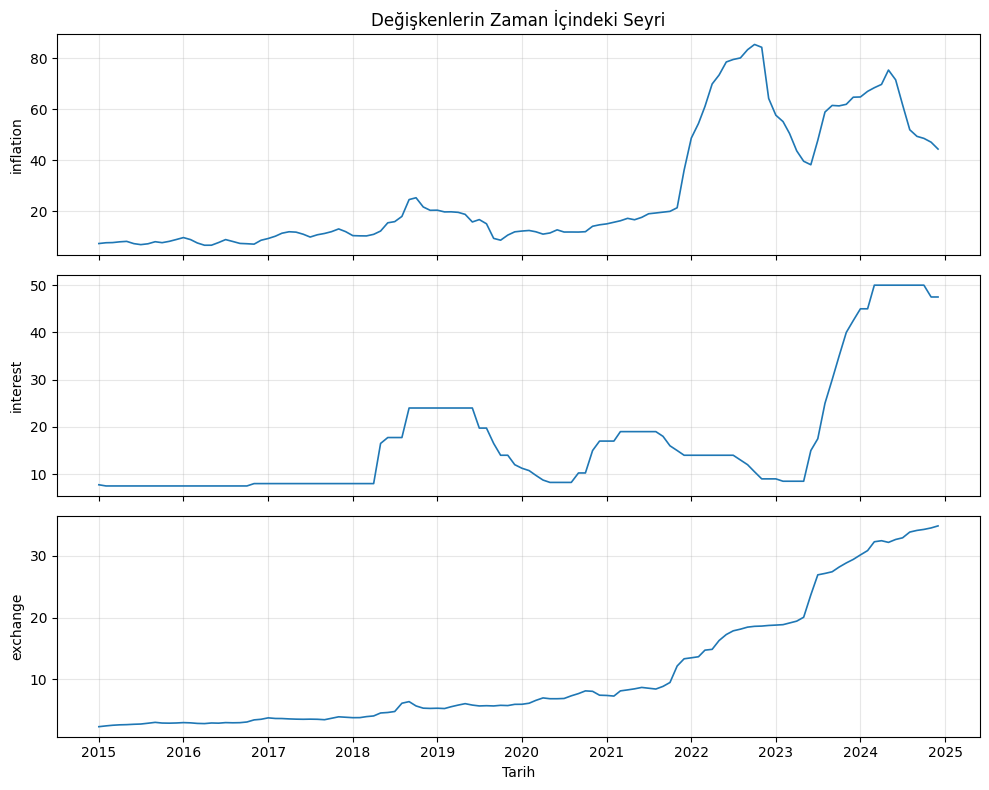

DURAĞANLIK TESTLERİ (ADF)

inflation:
  Test istatistiği : -0.8424
  p-değeri         : 0.8063
  Kullanılan gecikme: 13
  Kritik değerler  : %1: -3.494, %5: -2.889, %10: -2.582
  → Seri muhtemelen durağan değil (H0 reddedilemedi)
    Fark almak gerekebilir.

interest:
  Test istatistiği : -2.4512
  p-değeri         : 0.1278
  Kullanılan gecikme: 4
  Kritik değerler  : %1: -3.489, %5: -2.887, %10: -2.580
  → Seri muhtemelen durağan değil (H0 reddedilemedi)
    Fark almak gerekebilir.

exchange:
  Test istatistiği : 2.6488
  p-değeri         : 0.9991
  Kullanılan gecikme: 2
  Kritik değerler  : %1: -3.488, %5: -2.887, %10: -2.580
  → Seri muhtemelen durağan değil (H0 reddedilemedi)
    Fark almak gerekebilir.

GECİKME SEÇİMİ
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       13.78       13.85   9.607e+05       13.80
1       2.786       3.078       16.22       2.904
2       1.794    

c:\Users\hp\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


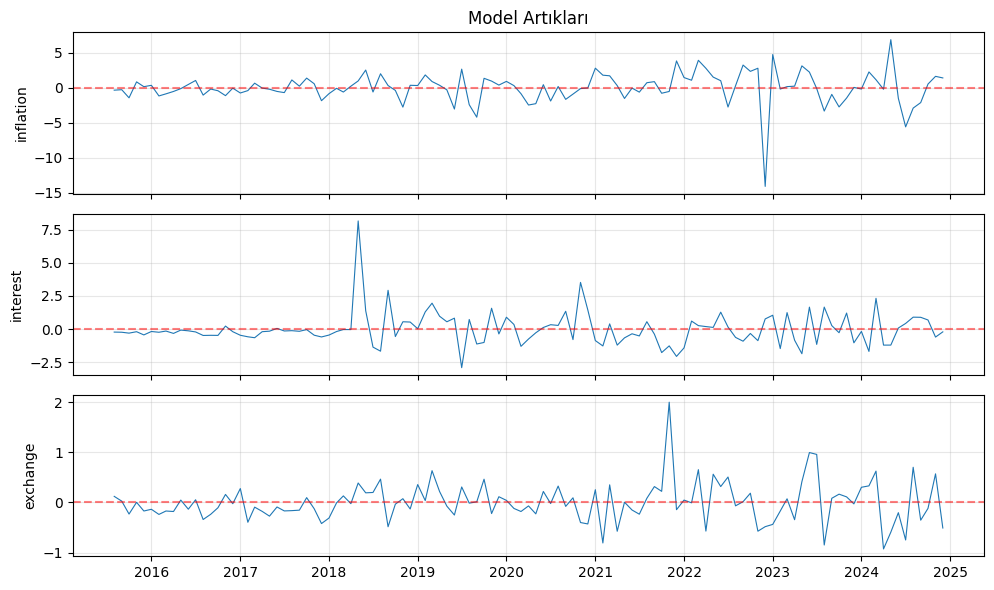


TAHMİN (FORECAST)

4 dönemlik tahminler:
            inflation  interest  exchange
2025-01-01      39.93     48.13     36.21
2025-02-01      40.19     49.20     38.00
2025-03-01      45.64     50.11     39.30
2025-04-01      52.08     51.40     40.16


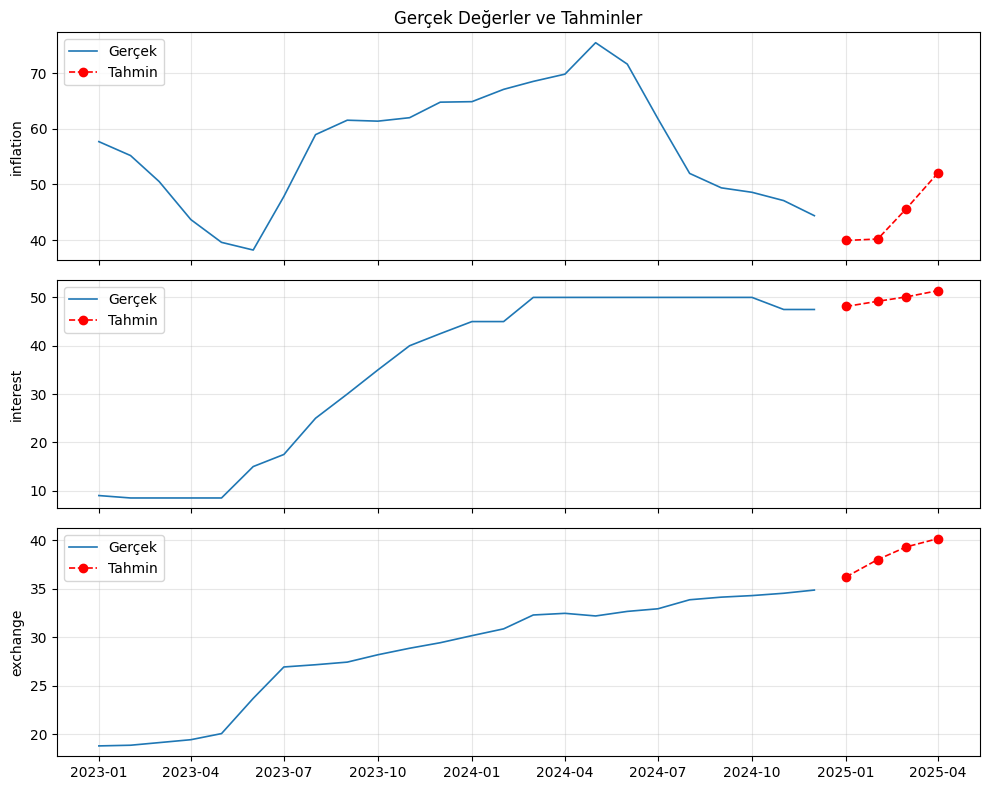


ETKİ-TEPKİ ANALİZİ (IRF)


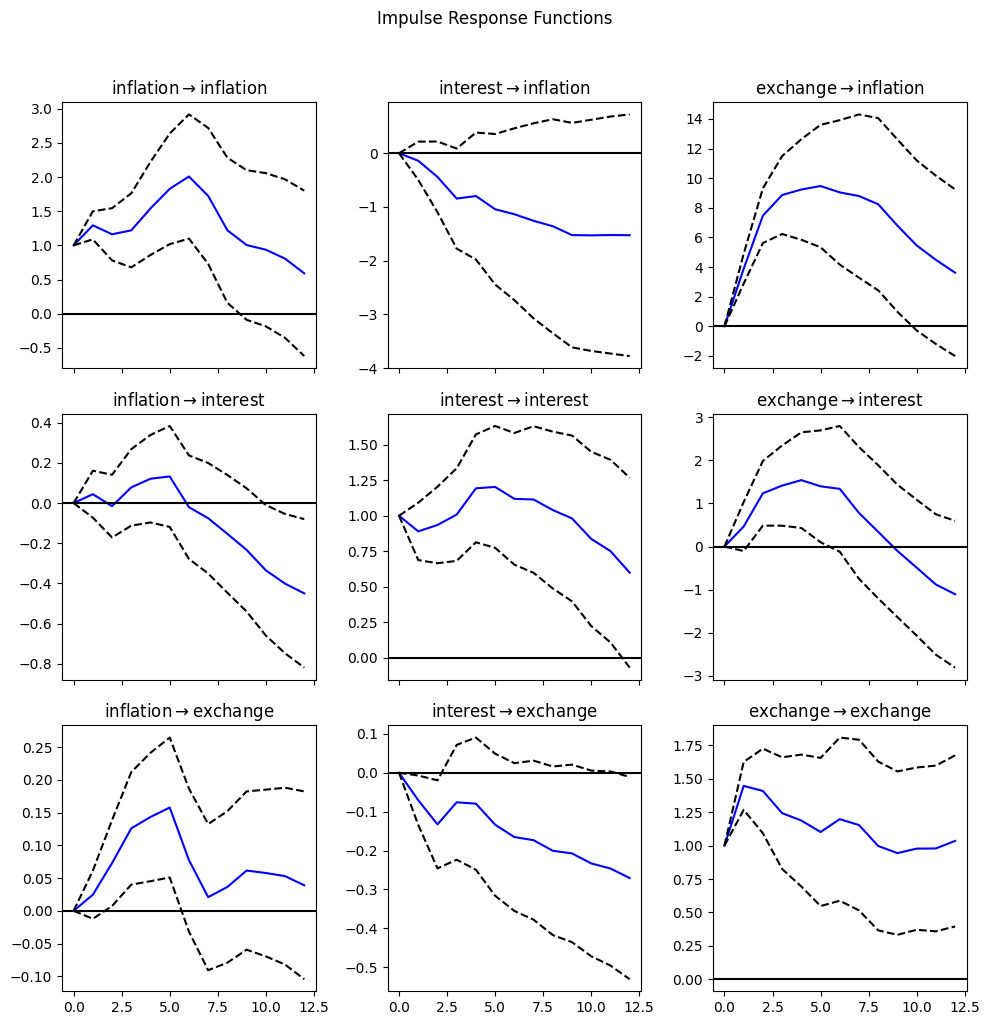

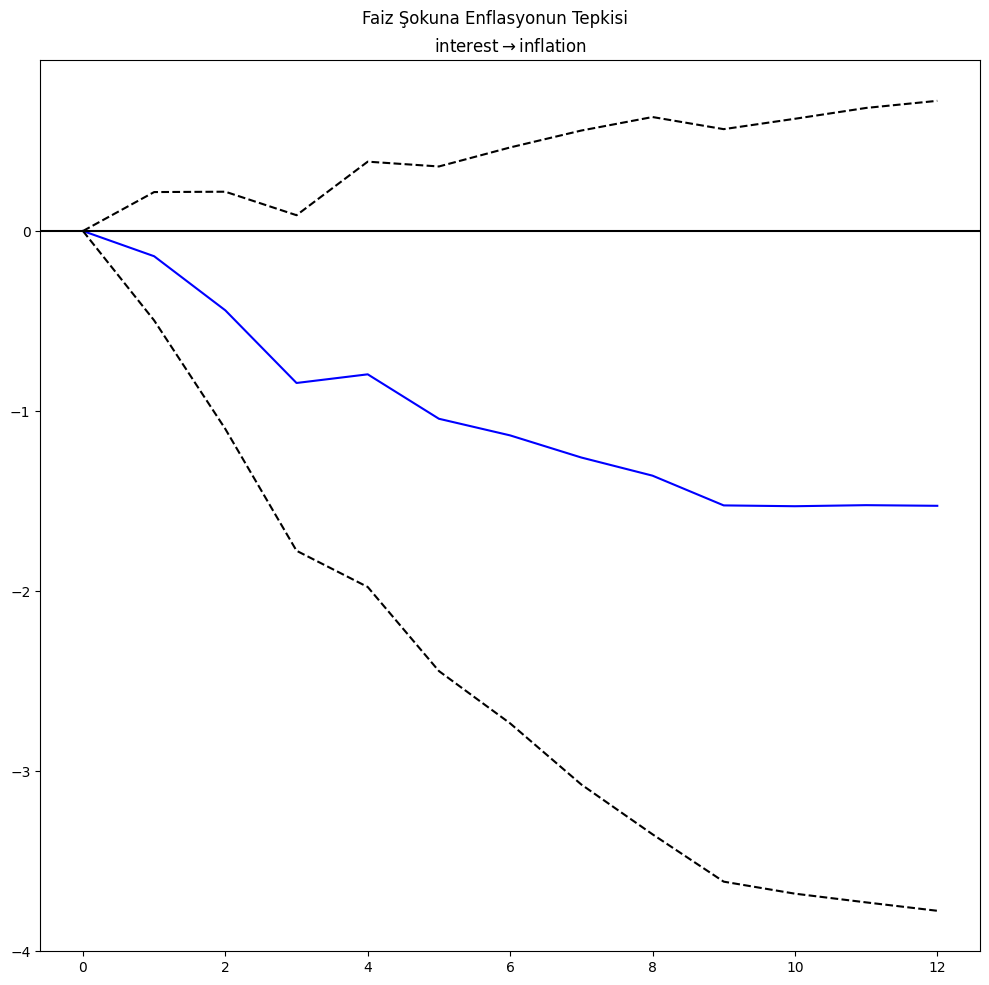

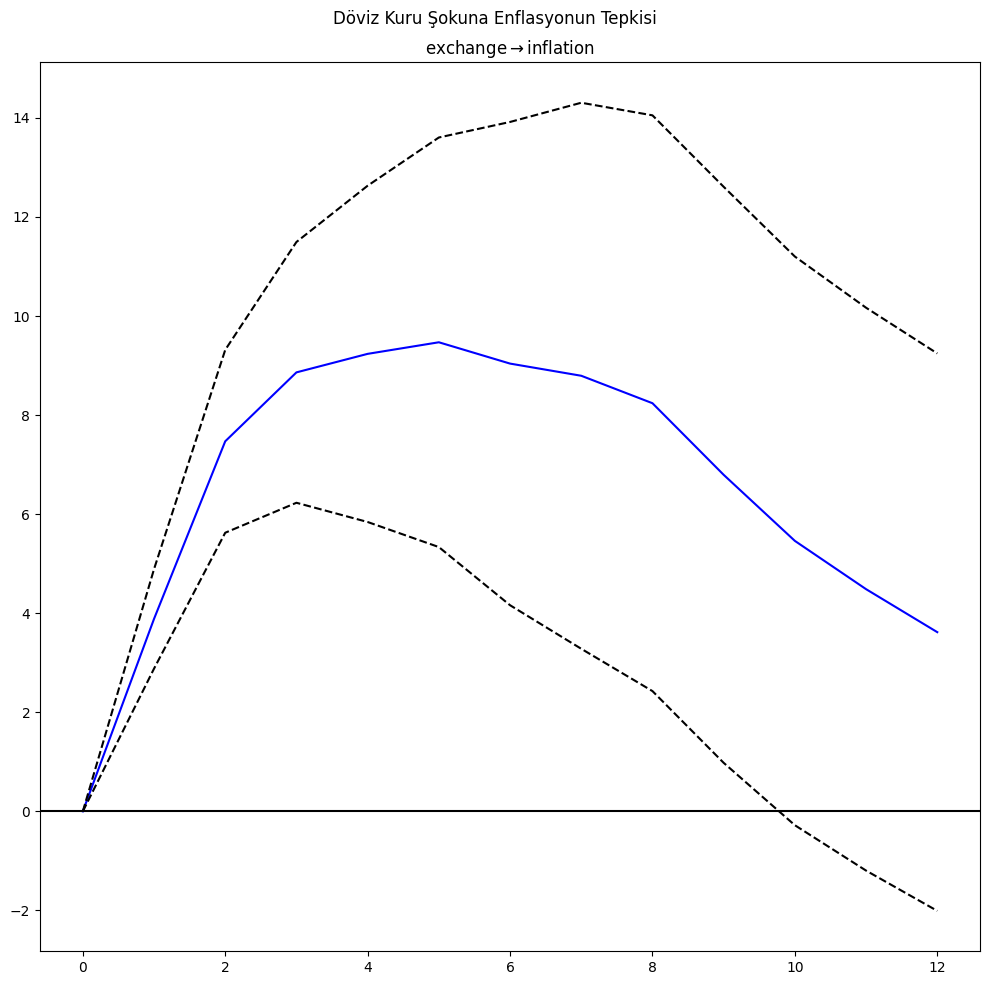


VARYANS AYRIŞTIRMASI (FEVD)
FEVD for inflation
      inflation  interest  exchange
0      1.000000  0.000000  0.000000
1      0.864530  0.000900  0.134571
2      0.689955  0.006194  0.303851
3      0.601784  0.018376  0.379840
4      0.585267  0.020554  0.394179
5      0.591412  0.025249  0.383340
6      0.607117  0.029084  0.363799
7      0.605927  0.034515  0.359559
8      0.592138  0.041834  0.366028
9      0.581123  0.051987  0.366890
10     0.574729  0.061904  0.363367
11     0.569309  0.071654  0.359037

FEVD for interest
      inflation  interest  exchange
0      0.012166  0.987834  0.000000
1      0.006722  0.981814  0.011464
2      0.005842  0.935224  0.058934
3      0.006468  0.905241  0.088291
4      0.009050  0.889024  0.101926
5      0.010989  0.884828  0.104183
6      0.010130  0.883250  0.106621
7      0.013347  0.888349  0.098303
8      0.023698  0.887486  0.088816
9      0.043062  0.876596  0.080343
10     0.075317  0.849635  0.075048
11     0.114584  0.811921  0.0734

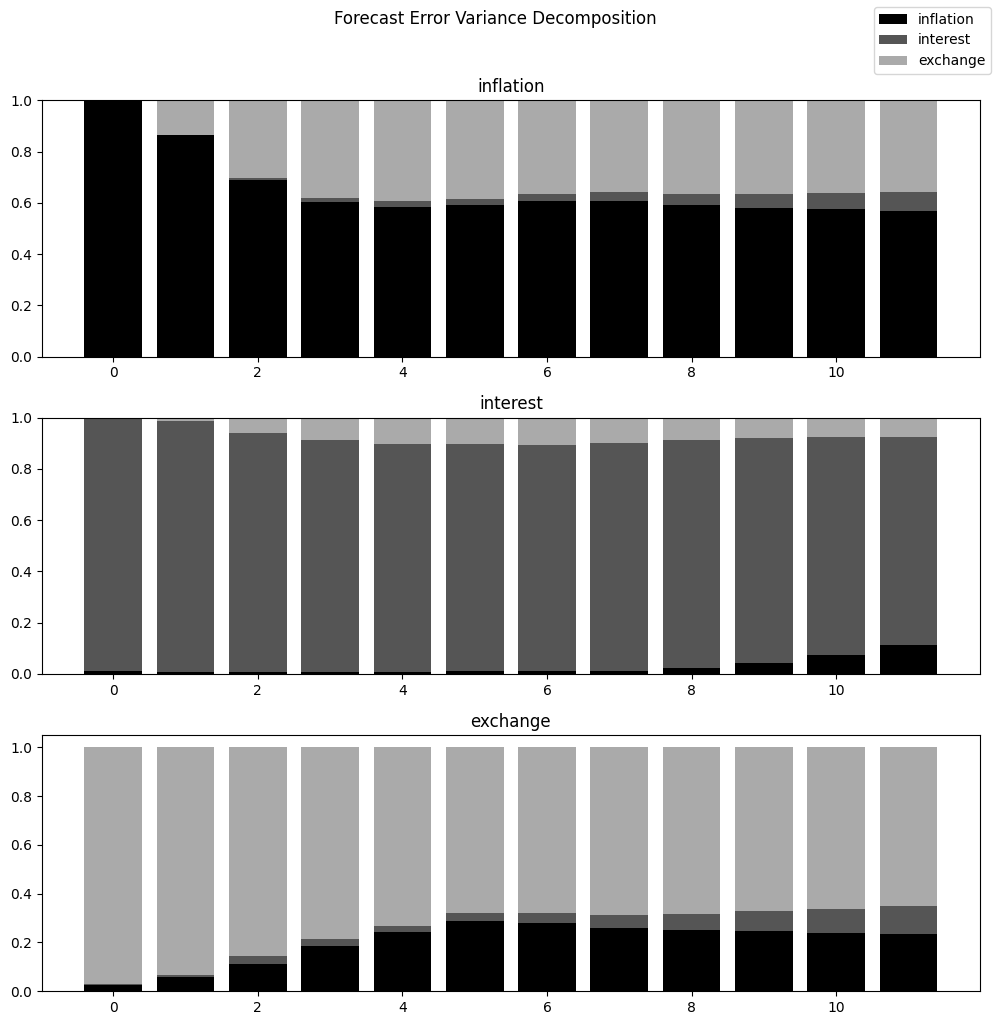


GRANGER NEDENSELLİK TESTLERİ

1) Faiz → Enflasyon:
Granger causality F-test. H_0: interest does not Granger-cause inflation. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.7479          2.043   0.632 (7, 273)
----------------------------------------------

2) Döviz Kuru → Enflasyon:
Granger causality F-test. H_0: exchange does not Granger-cause inflation. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         10.88          2.043   0.000 (7, 273)
----------------------------------------------

3) Enflasyon → Faiz:
Granger causality F-test. H_0: inflation does not Granger-cause interest. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         2.960          2.043   0.005 (7, 273)
----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

# =======================================================
# 1) VERİ SETİNİ OKUMA VE TEMEL HAZIRLIK
# =======================================================
#
# VAR analizi birden fazla zaman serisinin birlikte nasıl hareket ettiğini
# inceler. Elimizde üç makroekonomik değişken var:
#
#   - inflation : Yıllık enflasyon oranı (%)
#   - interest  : Merkez bankası politika faizi (%)
#   - exchange  : Döviz kuru (USD/TRY)
#
# Bu üç değişken ekonomide birbirini etkiler. Örneğin merkez bankası
# enflasyonu kontrol etmek için faizi artırabilir; faiz artışı döviz
# kurunu etkileyebilir; döviz kuru da ithal mallar üzerinden enflasyonu
# etkileyebilir. VAR modeli bu karşılıklı etkileşimleri yakalamaya çalışır.

df = pd.read_csv("macro.csv", parse_dates=["date"], index_col="date")

# Çalışacağımız değişkenleri seçiyoruz.
# dropna() ile eksik gözlem içeren satırları çıkarıyoruz çünkü
# VAR modeli eksik veri kaldırmaz.
vars_selected = ["inflation", "interest", "exchange"]
df_var = df[vars_selected].dropna()

print("Veri setinin son gözlemleri:")
print(df_var.tail())
print(f"\nToplam gözlem sayısı: {len(df_var)}")

# Gözlem sayısı önemli. VAR modelinde her değişken için her gecikme
# ayrı bir parametre demek. 3 değişken ve 4 gecikme seçersek
# her denklemde 3 × 4 = 12 katsayı + 1 sabit = 13 parametre olur.
# Toplam 3 × 13 = 39 parametre tahmin edilecek. Gözlem sayısı bu
# parametreleri güvenilir şekilde tahmin etmeye yetmeli.


# =======================================================
# 2) SERİLERİN GÖRSELLEŞTİRİLMESİ
# =======================================================
#
# Analiz öncesi verilere bakmak her zaman iyi bir alışkanlıktır.
# Grafikler bize şunları söyleyebilir:
#   - Serilerde belirgin bir trend var mı?
#   - Yapısal kırılmalar (ani değişimler) var mı?
#   - Seriler birlikte hareket ediyor mu?
#
# Aşağıdaki grafikte 2018 ve 2021-2022 dönemlerinde sert hareketler
# göreceksiniz. Bunlar Türkiye ekonomisindeki kriz dönemlerine karşılık
# geliyor ve model bu tür aşırı hareketleri yakalamakta zorlanabilir.

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, col in enumerate(vars_selected):
    axes[i].plot(df_var.index, df_var[col], linewidth=1.2)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Değişkenlerin Zaman İçindeki Seyri")
axes[2].set_xlabel("Tarih")
plt.tight_layout()
plt.show()


# =======================================================
# 3) DURAĞANLIK TESTİ (ADF)
# =======================================================
#
# Durağanlık kavramı zaman serisi analizinin temel taşlarından biridir.
# Bir seri durağansa:
#   - Ortalaması zaman içinde sabit kalır
#   - Varyansı zaman içinde sabit kalır
#   - İki dönem arasındaki korelasyon sadece aralarındaki uzaklığa bağlıdır
#
# Neden önemli? Durağan olmayan serilerle çalışırsak sahte (spurious)
# ilişkiler bulabiliriz. İki seri sadece ikisi de yukarı gittiği için
# ilişkili görünebilir, gerçekte aralarında anlamlı bir bağ olmasa bile.
#
# ADF (Augmented Dickey-Fuller) testi şu hipotezleri sınar:
#   H0: Seri durağan değildir (birim kök vardır)
#   H1: Seri durağandır
#
# p-değeri 0.05'ten küçükse H0'ı reddederiz ve serinin durağan olduğunu
# kabul ederiz. p-değeri büyükse seri muhtemelen durağan değildir ve
# fark almamız gerekir.

def adf_test(series, name):
    """
    ADF testi uygular ve sonuçları yorumlar.
    
    Test istatistiği kritik değerlerden küçükse (daha negatifse)
    veya p-değeri 0.05'ten küçükse seri durağan kabul edilir.
    """
    result = adfuller(series, autolag="AIC")
    
    # adfuller fonksiyonu bir tuple döndürür:
    # [0]: Test istatistiği
    # [1]: p-değeri
    # [2]: Kullanılan gecikme sayısı
    # [3]: Gözlem sayısı
    # [4]: Kritik değerler (dictionary)
    
    test_stat = result[0]
    p_value = result[1]
    used_lag = result[2]
    critical_values = result[4]
    
    print(f"\n{name}:")
    print(f"  Test istatistiği : {test_stat:.4f}")
    print(f"  p-değeri         : {p_value:.4f}")
    print(f"  Kullanılan gecikme: {used_lag}")
    print(f"  Kritik değerler  : %1: {critical_values['1%']:.3f}, "
          f"%5: {critical_values['5%']:.3f}, "
          f"%10: {critical_values['10%']:.3f}")
    
    # Yorum
    if p_value < 0.05:
        print("  → Seri durağan görünüyor (H0 reddedildi)")
    else:
        print("  → Seri muhtemelen durağan değil (H0 reddedilemedi)")
        print("    Fark almak gerekebilir.")

print("=" * 55)
print("DURAĞANLIK TESTLERİ (ADF)")
print("=" * 55)

for col in vars_selected:
    adf_test(df_var[col], col)

# -------------------------------------------------------
# Durağan olmayan serilerle ne yapılır?
# -------------------------------------------------------
#
# En yaygın çözüm birinci fark almaktır:
#   Δy_t = y_t - y_{t-1}
#
# Örneğin enflasyon durağan değilse:
#   df_var["inflation_d"] = df_var["inflation"].diff()
#
# Fark alınca ilk gözlem kaybolur (NaN olur), dropna() ile temizlenir.
# Fark alınmış seri için tekrar ADF testi yapılır.
#
# Bu örnekte eğitim amaçlı orijinal serilerle devam ediyoruz.
# Gerçek bir çalışmada durağan olmayan seriler mutlaka dönüştürülmelidir.


# =======================================================
# 4) VAR MODELİNİN KURULMASI VE GECİKME SEÇİMİ
# =======================================================
#
# VAR(p) modelinde p, kaç dönem geriye bakacağımızı belirler.
# p = 2 seçersek model şöyle görünür:
#
#   y_t = c + A1 * y_{t-1} + A2 * y_{t-2} + e_t
#
# Burada y_t bir vektör (3 değişkenimiz var), A1 ve A2 katsayı
# matrisleri, e_t ise hata terimleri vektörüdür.
#
# Gecikme sayısını nasıl seçeriz?
# -------------------------------------------------------
# Bilgi kriterleri bize yardımcı olur:
#
#   AIC (Akaike)      : Daha esnek, fazla gecikmeye izin verebilir
#   BIC (Bayesian)    : Parametre sayısını daha çok cezalandırır, tutucu
#   HQIC (Hannan-Quinn): İkisinin arasında
#
# Bu kriterler "model ne kadar iyi uyum sağlıyor" ile "kaç parametre
# kullanıyor" arasında denge kurar. Düşük değer daha iyidir.

model = VAR(df_var)

# maxlags=8 diyerek 1'den 8'e kadar tüm gecikmeleri deniyoruz.
# Her biri için AIC, BIC, HQIC hesaplanıyor.
lag_order_results = model.select_order(maxlags=8)

print("\n" + "=" * 55)
print("GECİKME SEÇİMİ")
print("=" * 55)
print(lag_order_results.summary())

# Her kriterin önerdiği gecikme farklı olabilir.
# selected_orders dictionary'si bize en iyi gecikmeleri verir.
print("\nKriterlere göre önerilen gecikmeler:")
print(f"  AIC : {lag_order_results.selected_orders['aic']}")
print(f"  BIC : {lag_order_results.selected_orders['bic']}")
print(f"  HQIC: {lag_order_results.selected_orders['hqic']}")

# Genel kural:
#   - Öngörü (forecasting) amaçlıysa AIC tercih edilebilir
#   - Tutumlu (parsimonious) model isteniyorsa BIC tercih edilir
#   - Emin değilseniz BIC ile başlayın, sonuçlar yetersizse artırın

selected_lag = lag_order_results.selected_orders['aic']
print(f"\nSeçilen gecikme (AIC'ye göre): {selected_lag}")

# -------------------------------------------------------
# Modeli tahmin ediyoruz
# -------------------------------------------------------
# fit() fonksiyonu OLS (En Küçük Kareler) yöntemiyle her denklemi
# ayrı ayrı tahmin eder. VAR'da her denklem aynı açıklayıcı
# değişkenlere sahip olduğundan, denklem denklem OLS yapmak
# tüm sistemi birlikte tahmin etmekle aynı sonucu verir.

results = model.fit(selected_lag)

print("\n" + "=" * 55)
print("MODEL TAHMİN SONUÇLARI")
print("=" * 55)
print(results.summary())

# Özet tabloda her denklem için ayrı sonuçlar görürsünüz:
#   - Katsayılar (const, L1.inflation, L1.interest, vb.)
#   - Standart hatalar
#   - t-istatistikleri ve p-değerleri
#   - R-kare değerleri
#
# Katsayıların işaretleri ve büyüklükleri ekonomik açıdan
# yorumlanabilir, ancak VAR'da doğrudan yorum yapmak zordur.
# IRF ve FEVD bu yorumu kolaylaştırır.


# =======================================================
# 5) STABİLİTE KONTROLÜ
# =======================================================
#
# VAR modelinin anlamlı sonuçlar üretmesi için stabil olması gerekir.
# Stabilite ne demek?
#
# Matematiksel olarak: Karakteristik polinomun tüm kökleri birim
# çemberin içinde olmalıdır (mutlak değerleri 1'den küçük).
#
# Sezgisel olarak: Sisteme bir şok verildiğinde bu şokun etkisi
# zamanla sönmeli, patmamalıdır. Stabil olmayan bir sistemde
# küçük bir şok bile zamanla büyüyerek patlar.
#
# Stabil olmayan VAR ile:
#   - Impulse response fonksiyonları anlamsız olur
#   - Tahminler güvenilmez olur
#   - Varyans ayrıştırması yorumlanamaz

print("\n" + "=" * 55)
print("STABİLİTE KONTROLÜ")
print("=" * 55)

is_stable = results.is_stable()
print(f"Model stabil mi? {is_stable}")

if is_stable:
    print("Tüm kökler birim çemberin içinde - model stabil.")
else:
    print("UYARI: Köklerden bazıları birim çember dışında!")
    print("Model yeniden gözden geçirilmeli:")
    print("  - Gecikme sayısı değiştirilebilir")
    print("  - Seriler fark alınarak durağanlaştırılabilir")
    print("  - Aykırı gözlemler incelenebilir")

# Köklerin değerlerini de görebiliriz:
roots = results.roots
print(f"\nKarakteristik kökler (mutlak değerler):")
for i, root in enumerate(roots):
    print(f"  Kök {i+1}: {np.abs(root):.4f}")
print("(Tüm değerler 1'den küçük olmalı)")


# =======================================================
# 6) ARTIK (RESİDUAL) ANALİZİ
# =======================================================
#
# Model tahmini yaptıktan sonra artıkları incelemek önemlidir.
# Artıklar, modelin açıklayamadığı kısımdır:
#   e_t = y_t - ŷ_t (gerçek değer - tahmin edilen değer)
#
# İyi bir modelde artıklar:
#   - Ortalaması sıfır olmalı
#   - Otokorelasyon içermemeli (rastgele olmalı)
#   - Varyansı sabit olmalı (homoskedastik)
#
# Durbin-Watson istatistiği birinci derece otokorelasyonu ölçer:
#   DW ≈ 2    : Otokorelasyon yok (ideal)
#   DW < 2    : Pozitif otokorelasyon var
#   DW > 2    : Negatif otokorelasyon var
#
# DW değeri 1.5 ile 2.5 arasındaysa genellikle kabul edilebilir.

print("\n" + "=" * 55)
print("ARTIK ANALİZİ")
print("=" * 55)

residuals = results.resid
dw_stats = durbin_watson(residuals)

print("\nDurbin-Watson istatistikleri:")
for i, col in enumerate(vars_selected):
    dw = dw_stats[i]
    # Basit bir yorum ekleyelim
    if 1.5 <= dw <= 2.5:
        yorum = "kabul edilebilir"
    elif dw < 1.5:
        yorum = "pozitif otokorelasyon olabilir"
    else:
        yorum = "negatif otokorelasyon olabilir"
    print(f"  {col}: {dw:.3f} ({yorum})")

print("\n  Not: 2'ye yakın değerler otokorelasyon olmadığını gösterir.")

# Artıkların grafiği
# Rastgele dağılmış, belirgin bir örüntü göstermeyen artıklar isteriz.
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for i, col in enumerate(vars_selected):
    axes[i].plot(residuals.index, residuals[col], linewidth=0.8)
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Model Artıkları")
plt.tight_layout()
plt.show()

# Grafikte artıklar sıfır çizgisi etrafında rastgele dağılmalı.
# Belirgin trendler, periyodik örüntüler veya değişen varyans
# (önce küçük sonra büyük dalgalanmalar gibi) model sorunlarına işaret eder.


# =======================================================
# 7) KISA DÖNEM TAHMİN (FORECAST)
# =======================================================
#
# VAR modelinin pratik kullanımlarından biri öngörü yapmaktır.
# Model geçmiş ilişkileri öğrenmiştir; bu ilişkilerin gelecekte
# de geçerli olacağını varsayarak tahmin üretir.
#
# Tahmin yapmak için son 'p' gözleme ihtiyacımız var (p = gecikme sayısı).
# Bu gözlemler modele başlangıç noktası olarak verilir.
#
# Dikkat: VAR tahminleri kısa vadede genellikle makul sonuçlar verir
# ancak uzun vadede belirsizlik hızla artar. 1-4 dönemlik tahminler
# güvenilirken, 12+ dönemlik tahminler çok geniş güven aralıklarına sahiptir.

print("\n" + "=" * 55)
print("TAHMİN (FORECAST)")
print("=" * 55)

forecast_horizon = 4  # 4 dönem (ay) ileriye tahmin

# Son 'selected_lag' gözlemi başlangıç değeri olarak alıyoruz
lagged_values = df_var.values[-selected_lag:]

# Tahmin üret
forecast_values = results.forecast(y=lagged_values, steps=forecast_horizon)

# Tahmin için tarih indeksi oluşturma
# pd.infer_freq() bazen None dönebilir, bu durumu ele alıyoruz
freq = pd.infer_freq(df_var.index)
if freq is None:
    freq = 'MS'  # Month Start - ay başı
    print(f"Frekans otomatik belirlenemedi, '{freq}' varsayıldı.")

# Son gözlemden sonraki tarihleri oluştur
idx_forecast = pd.date_range(
    start=df_var.index[-1] + pd.DateOffset(months=1),
    periods=forecast_horizon,
    freq=freq
)

df_forecast = pd.DataFrame(forecast_values, index=idx_forecast, columns=vars_selected)

print(f"\n{forecast_horizon} dönemlik tahminler:")
print(df_forecast.round(2))

# -------------------------------------------------------
# Tahminlerin görselleştirilmesi
# -------------------------------------------------------
# Gerçek değerlerle tahminleri yan yana görmek, modelin
# mantıklı sonuçlar üretip üretmediğini anlamaya yardımcı olur.

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(vars_selected):
    # Son 24 aylık gerçek değerler
    axes[i].plot(df_var.index[-24:], df_var[col].iloc[-24:], 
                 label='Gerçek', linewidth=1.2)
    # Tahminler
    axes[i].plot(df_forecast.index, df_forecast[col], 
                 'r--', label='Tahmin', linewidth=1.2, marker='o')
    axes[i].set_ylabel(col)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Gerçek Değerler ve Tahminler")
plt.tight_layout()
plt.show()

# Grafik yorumu:
# Tahminler mevcut trendin devamı gibi görünmeli.
# Çok keskin dönüşler veya mantıksız değerler (negatif enflasyon gibi)
# model sorunlarına işaret edebilir.


# =======================================================
# 8) IMPULSE RESPONSE FUNCTION (IRF) - ETKİ-TEPKİ ANALİZİ
# =======================================================
#
# IRF, VAR analizinin en önemli araçlarından biridir. Şu soruyu yanıtlar:
# "Bir değişkene verilen şokun diğer değişkenler üzerindeki etkisi
# zamanla nasıl gelişir?"
#
# Örneğin faize bir birimlik şok verildiğinde:
#   - Enflasyon nasıl tepki verir?
#   - Döviz kuru nasıl tepki verir?
#   - Bu etkiler kaç dönem sürer?
#
# IRF grafikleri şöyle okunur:
#   - Yatay eksen: Dönem sayısı (şoktan sonra geçen süre)
#   - Dikey eksen: Tepkinin büyüklüğü
#   - Sıfır çizgisi: Tepki yok
#   - Çizgi sıfırın üstündeyse: Pozitif tepki
#   - Çizgi sıfırın altındaysa: Negatif tepki
#
# Güven bantları (confidence bands) da gösterilir. Bantlar geniş ise
# o dönemdeki tepki istatistiksel olarak belirsizdir.

print("\n" + "=" * 55)
print("ETKİ-TEPKİ ANALİZİ (IRF)")
print("=" * 55)

# 12 dönemlik (1 yıl) tepkileri hesapla
irf = results.irf(12)

# Tüm değişken çiftleri için IRF grafikleri
# Her satır bir şoku, her sütun o şoka verilen tepkiyi gösterir
fig_irf = irf.plot(orth=False)
plt.suptitle("Impulse Response Functions", y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Belirli bir şok-tepki çiftini inceleme
# -------------------------------------------------------
# Tüm grafiklere bakmak kafa karıştırıcı olabilir.
# Spesifik bir ilişkiyi incelemek daha aydınlatıcı olur.
#
# Örnek: Faiz şoku enflasyonu nasıl etkiler?
# Ekonomi teorisine göre faiz artışı enflasyonu düşürmeli
# (sıkı para politikası). Bunu veride görüyor muyuz?

fig_irf_pair = irf.plot(impulse="interest", response="inflation")
plt.suptitle("Faiz Şokuna Enflasyonun Tepkisi")
plt.tight_layout()
plt.show()

# Bir diğer ilginç ilişki: Döviz kuru şoku enflasyonu nasıl etkiler?
# Döviz kuru artışı (TL değer kaybı) ithal malları pahalılaştırarak
# enflasyonu artırmalı. Buna "exchange rate pass-through" denir.

fig_irf_exc = irf.plot(impulse="exchange", response="inflation")
plt.suptitle("Döviz Kuru Şokuna Enflasyonun Tepkisi")
plt.tight_layout()
plt.show()


# =======================================================
# 9) FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# =======================================================
#
# FEVD şu soruyu yanıtlar: "Bir değişkenin tahmin hatasının
# ne kadarı kendi şoklarından, ne kadarı diğer değişkenlerin
# şoklarından kaynaklanıyor?"
#
# Örneğin enflasyonun tahmin hatasının:
#   - %60'ı kendi şoklarından
#   - %25'i döviz kuru şoklarından
#   - %15'i faiz şoklarından
# kaynaklanıyor olabilir.
#
# Bu bilgi politika yapıcılar için değerlidir:
# Enflasyonu kontrol etmek istiyorsanız ve enflasyon üzerinde
# döviz kurunun etkisi büyükse, döviz kuru istikrarı öncelikli olmalı.
#
# FEVD tablolarında:
#   - Satırlar: Dönemler (1, 2, 3, ... n)
#   - Sütunlar: Her değişkenin katkı payı (toplam = 1 veya %100)
#   - Dönem arttıkça paylar stabilize olur

print("\n" + "=" * 55)
print("VARYANS AYRIŞTIRMASI (FEVD)")
print("=" * 55)

fevd = results.fevd(12)  # 12 dönemlik ufuk
print(fevd.summary())

# Grafik gösterimi
# Her değişken için ayrı bir grafik çizilir.
# Renkli alanlar her şokun katkı payını gösterir.
fig_fevd = fevd.plot()
plt.suptitle("Forecast Error Variance Decomposition", y=1.02)
plt.tight_layout()
plt.show()

# Grafik yorumu:
# İlk dönemlerde değişken genellikle kendi şoklarından etkilenir.
# Dönem sayısı arttıkça diğer değişkenlerin etkisi belirginleşir.
# Uzun dönemde paylar sabitlenir - bu "long-run" etkiyi gösterir.


# =======================================================
# 10) GRANGER NEDENSELLİK TESTLERİ
# =======================================================
#
# Granger nedenselliği, günlük dildeki nedensellikten farklıdır.
# "X, Y'yi Granger-nedensel olarak açıklıyor" demek şu anlama gelir:
# "X'in geçmiş değerleri, Y'nin tahminini iyileştiriyor."
#
# Bu mutlaka gerçek bir neden-sonuç ilişkisi olduğunu göstermez.
# Her iki seri de üçüncü bir değişkenden etkileniyor olabilir.
# Yine de Granger nedenselliği öngörü ilişkilerini anlamak için faydalıdır.
#
# Test şöyle çalışır:
#   H0: X'in geçmiş değerleri, Y denklemine ek bilgi katmıyor
#       (Granger nedenselliği yok)
#   H1: X'in geçmiş değerleri, Y'nin tahminini iyileştiriyor
#       (Granger nedenselliği var)
#
# p-değeri 0.05'ten küçükse H0 reddedilir ve Granger nedenselliği
# olduğu kabul edilir.

print("\n" + "=" * 55)
print("GRANGER NEDENSELLİK TESTLERİ")
print("=" * 55)

# Test 1: Faiz → Enflasyon
# Soru: Faizin geçmiş değerleri enflasyonu öngörmede yardımcı mı?
gc_int_inf = results.test_causality(
    caused="inflation",      # Etkilenen (bağımlı) değişken
    causing=["interest"],    # Etkileyen (açıklayıcı) değişken
    kind="f"                 # F-testi kullan
)
print("\n1) Faiz → Enflasyon:")
print(gc_int_inf.summary())

# Test 2: Döviz kuru → Enflasyon
# Soru: Döviz kurunun geçmiş değerleri enflasyonu öngörmede yardımcı mı?
gc_exc_inf = results.test_causality(
    caused="inflation",
    causing=["exchange"],
    kind="f"
)
print("\n2) Döviz Kuru → Enflasyon:")
print(gc_exc_inf.summary())

# Test 3: Enflasyon → Faiz
# Soru: Merkez bankası enflasyona tepki veriyor mu?
# Enflasyon-hedeflemesi yapan bir merkez bankası için
# bu ilişkiyi beklerdik.
gc_inf_int = results.test_causality(
    caused="interest",
    causing=["inflation"],
    kind="f"
)
print("\n3) Enflasyon → Faiz:")
print(gc_inf_int.summary())

# Test 4: Döviz kuru → Faiz
# Soru: Merkez bankası döviz kuruna tepki veriyor mu?
gc_exc_int = results.test_causality(
    caused="interest",
    causing=["exchange"],
    kind="f"
)
print("\n4) Döviz Kuru → Faiz:")
print(gc_exc_int.summary())

# -------------------------------------------------------
# Sonuçların yorumlanması
# -------------------------------------------------------
# p-değeri < 0.05 ise Granger nedenselliği var diyoruz.
# Çift yönlü nedensellik de mümkündür:
#   - Enflasyon faizi etkiler (merkez bankası tepki verir)
#   - Faiz de enflasyonu etkiler (para politikası çalışır)
# Bu tür karşılıklı etkileşimler VAR modelinin varlık sebebidir.


# =======================================================
# ÖZET VE SONUÇ
# =======================================================
print("\n" + "=" * 55)
print("ANALİZ TAMAMLANDI")
print("=" * 55)
print("""
Bu VAR analizinde şunları yaptık:

1. Verileri hazırladık ve görselleştirdik
2. Durağanlığı ADF testi ile kontrol ettik
3. Bilgi kriterleriyle optimal gecikme sayısını belirledik
4. Modeli tahmin ettik ve stabilitesini kontrol ettik
5. Artıkları inceleyerek model uyumunu değerlendirdik
6. Kısa dönem tahminler ürettik
7. IRF ile şokların yayılımını analiz ettik
8. FEVD ile varyans kaynaklarını ayrıştırdık
9. Granger nedensellik testleri ile öngörü ilişkilerini inceledik

Unutulmaması gerekenler:
- VAR sonuçları sadece korelasyon/öngörü ilişkilerini gösterir,
  gerçek nedensellik için ek analizler gerekir.
- Durağan olmayan serilerle çalışmak sahte ilişkilere yol açabilir.
- Yapısal kırılmalar (kriz dönemleri) model performansını etkiler.
- Kısa dönem tahminler uzun döneme göre daha güvenilirdir.
""")